In [1]:
!pip install torch torchvision opencv-python matplotlib timm

   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.6 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.6 MB 1.9 MB/s eta 0:00:02
   --------------- ------------------------ 1.0/2.6 MB 2.2 MB/s eta 0:00:01
   ----------------------- ---------------- 1.6/2.6 MB 2.3 MB/s eta 0:00:01
   ----------------------------------- ---- 2.4/2.6 MB 2.6 MB/s eta 0:00:01
   ---------------------------------------- 2.6/2.6 MB 2.7 MB/s  0:00:01


Using cache found in C:\Users\mchin/.cache\torch\hub\intel-isl_MiDaS_master
Using cache found in C:\Users\mchin/.cache\torch\hub\intel-isl_MiDaS_master


Image loaded successfully.


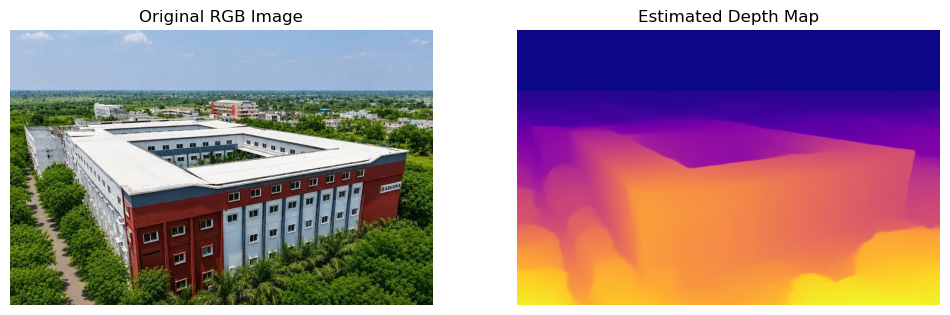

In [3]:
import cv2
import torch
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Load MiDaS model
# --------------------------------------------------

model_type = "DPT_Large"

midas = torch.hub.load("intel-isl/MiDaS", model_type)

# Select CPU or GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

midas.to(device)
midas.eval()

# --------------------------------------------------
# 2. Load MiDaS transformation
# --------------------------------------------------

midas_transforms = torch.hub.load(
    "intel-isl/MiDaS", 
    "transforms"
)

transform = midas_transforms.dpt_transform

# --------------------------------------------------
# 3. Read input image
# --------------------------------------------------

img = cv2.imread("images.jpg")



if img is None:
    print("Error: Image not found!")
else:
    print("Image loaded successfully.")

# Convert BGR → RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# --------------------------------------------------
# 4. Prepare image for MiDaS
# --------------------------------------------------

input_batch = transform(img_rgb).to(device)

# --------------------------------------------------
# 5. Predict depth
# --------------------------------------------------

with torch.no_grad():
    prediction = midas(input_batch)

    prediction = torch.nn.functional.interpolate(
        prediction.unsqueeze(1),
        size=img_rgb.shape[:2],
        mode="bicubic",
        align_corners=False
    ).squeeze()

depth = prediction.cpu().numpy()

# --------------------------------------------------
# 6. Display original image
# --------------------------------------------------

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original RGB Image")
plt.axis("off")

# --------------------------------------------------
# 7. Display estimated depth
# --------------------------------------------------

plt.subplot(1, 2, 2)
plt.imshow(depth, cmap="plasma")
plt.title("Estimated Depth Map")
plt.axis("off")

plt.show()